## SafeDerm — 06. Baseline Model

First real model: plain ResNet-50, ImageNet-pretrained, fine-tuned on the training split. This is the baseline `07_champion_model.ipynb`'s CNN+Transformer architecture gets compared against — no transformer head, no calibration, no tricks. Just a solid, honest number to beat.

Model and training/eval loops live in `src/model.py` and `src/engine.py` — `07` reuses these exact functions, so any difference in results reflects the architecture, not a difference in how each was trained or measured.

**Updated training recipe** (see `docs/decisions/ADR-006-training-recipe-and-champion-model.md`): backbone-freeze warmup, discriminative learning rates, weight decay, LR scheduling, and early stopping replace the original single-LR/fixed-epoch loop -- the original run overfit past epoch 5 (val_loss never beat epoch 5's again through epoch 10, while train_loss kept falling). Architecture is unchanged; only the recipe is. "No tricks" above means the architecture, not the training hygiene -- a properly-trained plain ResNet-50 is still the honest number `07` needs to beat.

### Reproducibility

`set_seed(42)` below seeds python/numpy/torch so this run's weight init, dropout, augmentation, and shuffling are reproducible run-to-run -- ADR-003's `random_state=42` only covered the data *split*, not the training run itself.

In [1]:
import logging

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import DataLoader

from src.config import IMAGES_DIR, TRAIN_SPLIT_PATH, VAL_SPLIT_PATH, MODELS_DIR, BASELINE_MODEL_PATH
from src.dataset import SkinLesionDataset, CLASS_TO_IDX
from src.transforms import get_train_transforms, get_eval_transforms
from src.model import build_baseline_model
from src.engine import (
    set_seed, compute_class_weights, train_one_epoch, evaluate, malignant_recall,
    get_param_groups, freeze_backbone, unfreeze_all, EarlyStopper, fit,
)
from src.labels import ALL_CLASSES, MALIGNANT_CLASSES

# src/engine.py logs progress via the logging module (not print) since it's
# library code, not notebook code -- this makes that progress visible here.
logging.basicConfig(level=logging.INFO, format="%(message)s")

set_seed(42)

BATCH_SIZE = 32
WARMUP_EPOCHS = 2         # phase 1: backbone frozen, head only
MAX_EPOCHS = 30           # phase 2 ceiling -- EarlyStopper should stop well short of this
HEAD_LR = 1e-3
BACKBONE_LR = 1e-5
WEIGHT_DECAY = 1e-4
EARLY_STOP_PATIENCE = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


`HEAD_LR`, `BACKBONE_LR`, `WEIGHT_DECAY`, and the scheduler/early-stopping settings are reasonable starting points, not exhaustively tuned -- `MAX_EPOCHS` is a ceiling `EarlyStopper` should stop well short of. Adjust based on how the training curves look below.

### Rebuild the pipeline

Same `Dataset`/`DataLoader` setup as `05_pipeline.ipynb` — repeated here so this notebook can run standalone, not because the logic changed.

In [2]:
train_dataset = SkinLesionDataset(TRAIN_SPLIT_PATH, IMAGES_DIR, transform=get_train_transforms())
val_dataset = SkinLesionDataset(VAL_SPLIT_PATH, IMAGES_DIR, transform=get_eval_transforms())

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")

Train batches: 219
Val batches  : 48


### Build model, loss, optimizer

Weighted `CrossEntropyLoss` — counters the ~67% `nv` imbalance confirmed in `03_eda.ipynb`. Without this, the model could hit high accuracy by just always predicting `nv`, which would look good on paper and be useless in practice.

Training happens in two phases (ADR-006): a short warmup with the backbone frozen (only the head learns), then the full model unfrozen with a lower learning rate on the pretrained backbone than on the head. Fine-tuning all 25M ResNet parameters at one LR from the start is what overfit the original run -- the backbone moved too fast, away from its useful ImageNet features, before the head had learned anything sensible to guide it.

In [3]:
model = build_baseline_model().to(device)

class_weights = compute_class_weights(TRAIN_SPLIT_PATH).to(device)
print("Class weights (order matches ALL_CLASSES):")
for cls, w in zip(ALL_CLASSES, class_weights.tolist()):
    print(f"  {cls}: {w:.3f}")

criterion = nn.CrossEntropyLoss(weight=class_weights)


Class weights (order matches ALL_CLASSES):
  akiec: 4.492
  bcc: 2.763
  bkl: 1.292
  df: 14.046
  mel: 1.290
  nv: 0.213
  vasc: 10.074


### Phase 1 -- warmup (head only)

Backbone frozen, only the newly-initialized `fc` layer trains. Keeps the (random, untrained) head's early noisy gradients from being backpropagated into -- and disturbing -- the pretrained backbone.

In [4]:
freeze_backbone(model, head_attr="fc")
print(f"Phase 1: warmup -- backbone frozen, training only the head for {WARMUP_EPOCHS} epoch(s)")

warmup_optimizer = torch.optim.AdamW(model.fc.parameters(), lr=HEAD_LR, weight_decay=WEIGHT_DECAY)
for epoch in range(1, WARMUP_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, warmup_optimizer, criterion, device)
    val_loss, val_accuracy, _, _ = evaluate(model, val_loader, criterion, device)
    print(f"  warmup epoch {epoch}/{WARMUP_EPOCHS} — train_loss: {train_loss:.4f}  val_loss: {val_loss:.4f}  val_acc: {val_accuracy:.4f}")


Phase 1: warmup -- backbone frozen, training only the head for 2 epoch(s)
  warmup epoch 1/2 — train_loss: 1.5291  val_loss: 1.2513  val_acc: 0.5796
  warmup epoch 2/2 — train_loss: 1.2344  val_loss: 1.1342  val_acc: 0.6018


### Phase 2 -- fine-tune (discriminative LR, weight decay, scheduling, early stopping)

Unfreeze everything. `HEAD_LR` for the head, a much smaller `BACKBONE_LR` for the pretrained layers. `AdamW`'s decoupled weight decay adds L2 regularization the original `Adam` optimizer had none of. `ReduceLROnPlateau` drops the LR when val_loss stalls instead of grinding at a constant rate. `EarlyStopper` stops the run once val_loss hasn't improved in `EARLY_STOP_PATIENCE` epochs -- the original run kept going through epoch 10 despite val_loss already being worse than epoch 5's. Best checkpoint (lowest val_loss) still gets saved to `models/baseline_resnet50.pt`, same as before.

In [5]:
unfreeze_all(model)

optimizer = torch.optim.AdamW(
    get_param_groups(model, head_lr=HEAD_LR, backbone_lr=BACKBONE_LR, head_attr="fc"),
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
early_stopper = EarlyStopper(patience=EARLY_STOP_PATIENCE, mode="min")

MODELS_DIR.mkdir(parents=True, exist_ok=True)
history = fit(
    model, train_loader, val_loader, optimizer, criterion, device,
    checkpoint_path=BASELINE_MODEL_PATH, num_epochs=MAX_EPOCHS,
    scheduler=scheduler, early_stopper=early_stopper, selection_metric="val_loss",
)

print(f"\nStopped after epoch {history['stopped_epoch']} (best epoch: {history['best_epoch']})")


epoch 1/30 - train_loss=1.0323 val_loss=0.8761 val_acc=0.7030 malignant_recall=0.7435 lr=1.00e-03
  new best (val_loss=0.8761) - checkpoint saved to D:\Important\00-Projects\SafeDerm\models\baseline_resnet50.pt
epoch 2/30 - train_loss=0.8533 val_loss=0.8362 val_acc=0.6899 malignant_recall=0.7110 lr=1.00e-03
  new best (val_loss=0.8362) - checkpoint saved to D:\Important\00-Projects\SafeDerm\models\baseline_resnet50.pt
epoch 3/30 - train_loss=0.7015 val_loss=0.8545 val_acc=0.6860 malignant_recall=0.7760 lr=1.00e-03
epoch 4/30 - train_loss=0.6602 val_loss=0.9250 val_acc=0.6704 malignant_recall=0.7955 lr=1.00e-03
epoch 5/30 - train_loss=0.5824 val_loss=0.7861 val_acc=0.7206 malignant_recall=0.8149 lr=1.00e-03
  new best (val_loss=0.7861) - checkpoint saved to D:\Important\00-Projects\SafeDerm\models\baseline_resnet50.pt
epoch 6/30 - train_loss=0.5293 val_loss=0.8068 val_acc=0.7232 malignant_recall=0.8636 lr=1.00e-03
epoch 7/30 - train_loss=0.4934 val_loss=0.7228 val_acc=0.7369 malignant_r


Stopped after epoch 13 (best epoch: 9)


### Training curves

Third panel is new: malignant recall per epoch, alongside loss and accuracy -- the metric this project actually cares about, visible during training instead of only computed once at the end.

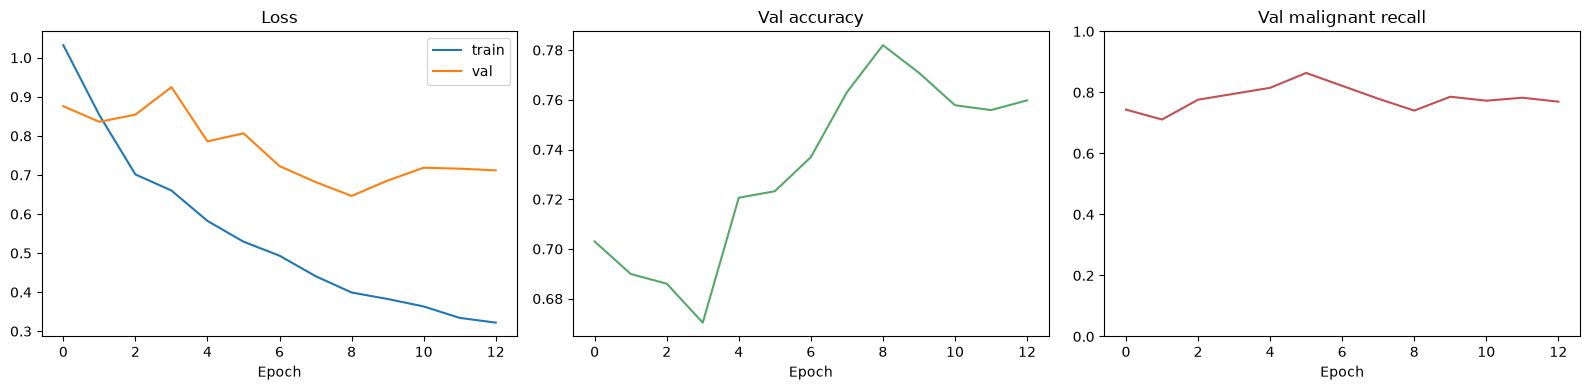

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["val_accuracy"], color="#55A868")
axes[1].set_title("Val accuracy")
axes[1].set_xlabel("Epoch")

axes[2].plot(history["malignant_recall"], color="#C44E52")
axes[2].set_title("Val malignant recall")
axes[2].set_xlabel("Epoch")
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()


### Evaluate the best checkpoint

Reload the best-saved weights (not whatever's left in memory from the last epoch) and evaluate properly — confusion matrix and full per-class report.

In [7]:
model.load_state_dict(torch.load(BASELINE_MODEL_PATH, map_location=device, weights_only=True))
val_loss, val_accuracy, val_preds, val_labels = evaluate(model, val_loader, criterion, device)

print(f"Best model — val_loss: {val_loss:.4f}  val_accuracy: {val_accuracy:.4f}")
print("\nClassification report:")
print(classification_report(val_labels, val_preds, target_names=ALL_CLASSES))


Best model — val_loss: 0.6464  val_accuracy: 0.7820

Classification report:
              precision    recall  f1-score   support

       akiec       0.42      0.60      0.49        53
         bcc       0.62      0.88      0.73        82
         bkl       0.48      0.60      0.54       160
          df       0.54      0.29      0.38        24
         mel       0.62      0.60      0.61       173
          nv       0.93      0.86      0.89      1018
        vasc       0.60      0.55      0.57        22

    accuracy                           0.78      1532
   macro avg       0.60      0.63      0.60      1532
weighted avg       0.80      0.78      0.79      1532



### Confusion matrix

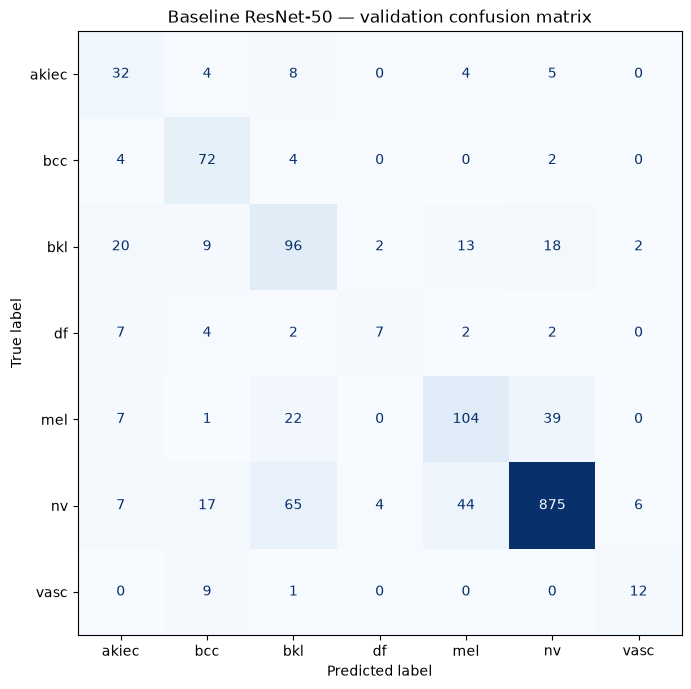

In [8]:
cm = confusion_matrix(val_labels, val_preds)
fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay(cm, display_labels=ALL_CLASSES).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Baseline ResNet-50 — validation confusion matrix")
plt.tight_layout()
plt.show()


### Recall on malignant -- the metric that actually matters

Overall accuracy is a weak proxy for this project's real goal. What matters: of all the actually-malignant lesions, how many did the model correctly flag? Missing one (a false negative) is the failure mode this project's safety framing exists to prevent -- see ADR-004.

Computed via `engine.malignant_recall()` now, not recomputed inline -- `07` and `08` call the same function instead of each re-deriving this.

In [9]:
recall_stats = malignant_recall(val_preds, val_labels)

print(f"Malignant lesions in val set: {recall_stats['malignant_total']}")
print(f"Correctly flagged (recall)  : {recall_stats['malignant_recall']:.3f}")
print(f"Missed (false negatives)    : {recall_stats['malignant_missed']}")


Malignant lesions in val set: 308
Correctly flagged (recall)  : 0.740
Missed (false negatives)    : 80


### Save metrics summary

Small JSON alongside the checkpoint, so `07_champion_model.ipynb` can load this result and print a direct comparison table instead of requiring someone to eyeball two notebooks side by side.

In [10]:
import json
from src.config import BASELINE_METRICS_PATH

metrics_summary = {
    "model_variant": "baseline",
    "val_loss": val_loss,
    "val_accuracy": val_accuracy,
    "malignant_recall": recall_stats["malignant_recall"],
    "malignant_missed": recall_stats["malignant_missed"],
    "malignant_total": recall_stats["malignant_total"],
    "best_epoch": history["best_epoch"],
    "stopped_epoch": history["stopped_epoch"],
}
BASELINE_METRICS_PATH.write_text(json.dumps(metrics_summary, indent=2))
print(f"Saved metrics summary to {BASELINE_METRICS_PATH}")
metrics_summary


Saved metrics summary to D:\Important\00-Projects\SafeDerm\models\baseline_metrics.json


{'model_variant': 'baseline',
 'val_loss': 0.6464247392884434,
 'val_accuracy': 0.7819843342036553,
 'malignant_recall': 0.7402597402597403,
 'malignant_missed': 80,
 'malignant_total': 308,
 'best_epoch': 9,
 'stopped_epoch': 13}

### Summary

- Baseline ResNet-50, now trained with the two-phase warmup + discriminative-LR + early-stopping recipe from ADR-006 (previously: single-LR full fine-tuning for a fixed 10 epochs, which overfit past epoch 5). Best checkpoint saved to `models/baseline_resnet50.pt`.
- Full per-class report and confusion matrix above -- **outputs in this notebook need a fresh run** with the updated recipe; numbers after a re-run will differ from (and should be more honest than) the original single-LR run.
- Malignant recall -- the actual safety metric -- computed via `engine.malignant_recall()`, shared with `07` and `08`.
- This is the number `07_champion_model.ipynb`'s CNN+Transformer architecture needs to beat, specifically on malignant recall, not just overall accuracy -- and now both notebooks train under the identical recipe, so the comparison isolates the architecture change.
- No calibration yet -- raw softmax probabilities aren't reliable confidence estimates. That's `08_calibration_conformal.ipynb`'s job.